# Customer Shopping Data — Comprehensive EDA

This notebook performs a full exploratory data analysis (EDA) on the Customer Shopping dataset. It follows a multi-phase structure: data inspection & cleaning, univariate analysis, bivariate/multivariate analysis, customer segmentation, statistical testing, and final insights & recommendations. Outputs (figures, CSVs, reports) are saved to the `analysis_output/` folder.

## Setup: Imports & Environment

This cell imports required libraries, sets plotting styles, and defines helper functions used throughout the notebook.

In [1]:
# Imports and global settings
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
import unicodedata
sns.set(style='whitegrid')
plt.rcParams.update({'font.size':12})
PROJECT_DIR = Path('.')
DATA_FILE = PROJECT_DIR / 'Customer_shopping_data_.csv'
OUTPUT_DIR = PROJECT_DIR / 'analysis_output'
OUTPUT_DIR.mkdir(exist_ok=True)
# Helper: save fig
def save_fig(fig, name):
    fig.savefig(OUTPUT_DIR / name, dpi=300, bbox_inches='tight')
# Helper: display pandas options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
print('Environment ready')

Environment ready


## Load dataset

Load the CSV into a DataFrame with memory-safe options. If file not found, the cell will print an error.

In [2]:
# Load data
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Data file not found: {DATA_FILE.resolve()}")
df = pd.read_csv(DATA_FILE)
print('Loaded:', DATA_FILE.name)
print('Shape:', df.shape)
df.head()

Loaded: Customer_shopping_data_.csv
Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55.0,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,NaN,Express,Yes,NaN,14,Venmo,Fortnightly
1,2,19.0,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,NaN,2,Cash,Fortnightly
2,3,50.0,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,NaN,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21.0,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,NaN,Yes,Next Day Air,Yes,NaN,49,PayPal,Weekly
4,5,NaN,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,NaN,Free Shipping,Yes,NaN,31,PayPal,Annually


## Quick Data Preview

Show head, tail, and a random sample for quick inspection.

In [3]:
display(df.head())
display(df.tail())
display(df.sample(5))
print('\nColumns:')
print(df.columns.tolist())

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55.0,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,NaN,Express,Yes,NaN,14,Venmo,Fortnightly
1,2,19.0,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,NaN,2,Cash,Fortnightly
2,3,50.0,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,NaN,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21.0,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,NaN,Yes,Next Day Air,Yes,NaN,49,PayPal,Weekly
4,5,NaN,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,NaN,Free Shipping,Yes,NaN,31,PayPal,Annually


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40.0,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,NaN,No,2-Day Shipping,No,NaN,32,Venmo,Weekly
3896,3897,NaN,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,NaN,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46.0,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,NaN,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44.0,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,NaN,No,Express,No,No,24,Venmo,Weekly
3899,3900,52.0,Female,Handbag,Accessories,81,California,M,Beige,Spring,NaN,No,Store Pickup,No,NaN,33,Venmo,Quarterly


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3715,3716,63.0,Female,Sunglasses,Accessories,34,Nebraska,S,Orange,Fall,3.4,No,Free Shipping,No,No,2,Bank Transfer,Monthly
3585,3586,39.0,Female,Gloves,Accessories,41,New York,XL,Gray,Winter,4.1,No,Standard,No,No,4,Venmo,Bi-Weekly
3338,3339,29.0,Female,Skirt,Clothing,94,Minnesota,L,White,Winter,2.9,No,2-Day Shipping,No,No,46,Credit Card,Monthly
3046,3047,60.0,Female,Shoes,Footwear,49,Pennsylvania,M,White,Spring,NaN,No,Store Pickup,No,No,25,Cash,Every 3 Months
2834,2835,39.0,Female,Jacket,Outerwear,43,Texas,M,Indigo,Fall,NaN,No,2-Day Shipping,No,No,17,Credit Card,Weekly



Columns:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


## DataFrame Info & Data Types

Show info(), memory usage, and convert obvious columns (IDs -> string, booleans/categoricals -> category, numeric conversions).

In [4]:
# Info & dtype conversions
print('Info:')
df.info()
print('\nMemory usage (MB):')
print(df.memory_usage(deep=True).sum()/1024**2)
# Convert obvious columns
if 'Customer ID' in df.columns:
    df['Customer ID'] = df['Customer ID'].astype(str)
for c in ['Gender','Category','Location','Size','Color','Season','Subscription Status','Shipping Type','Discount Applied','Promo Code Used','Payment Method','Frequency of Purchases']:
    if c in df.columns:
        df[c] = df[c].astype('category')
# Numeric conversions
for c in ['Purchase Amount (USD)','Age','Previous Purchases','Review Rating']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')
print('\nDtypes after conversion:')
print(df.dtypes)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     2903 non-null   float64
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           2685 non-null   float64
 11  Subscription Status     3084 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         2544 non-n

## Missing Values Analysis

Compute counts & percentages, and save a data quality report. Visualize missingness with a heatmap.

In [5]:
# Missing values summary
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(2)
miss_df = pd.concat([miss, miss_pct], axis=1)
miss_df.columns = ['missing_count','missing_pct']
miss_df.sort_values('missing_pct', ascending=False, inplace=True)
miss_df.to_csv(OUTPUT_DIR / 'missing_values_summary.csv')
print(miss_df.head(20))
# Heatmap of missingness (subset if many columns)
fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('Missingness Heatmap')
save_fig(fig, 'missingness_heatmap.png')
plt.close(fig)
with open(OUTPUT_DIR / 'data_quality_report.txt', 'w') as f:
    f.write('Missing Values Summary\n')
    f.write(miss_df.to_string())
print('Saved missing values report and heatmap')

                        missing_count  missing_pct
Promo Code Used                  1356        34.77
Review Rating                    1215        31.15
Age                               997        25.56
Subscription Status               816        20.92
Customer ID                         0         0.00
Gender                              0         0.00
Location                            0         0.00
Item Purchased                      0         0.00
Category                            0         0.00
Purchase Amount (USD)               0         0.00
Season                              0         0.00
Color                               0         0.00
Size                                0         0.00
Shipping Type                       0         0.00
Discount Applied                    0         0.00
Previous Purchases                  0         0.00
Payment Method                      0         0.00
Frequency of Purchases              0         0.00


Saved missing values report and heatmap


## Descriptive Statistics — Numeric & Categorical

Compute detailed numeric summary (including skewness & kurtosis) and categorical frequency tables.

In [6]:
# Numeric descriptive stats
num = df.select_dtypes(include=[np.number])
desc = num.describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99]).T
if not desc.empty:
    desc['skew'] = num.skew()
    desc['kurtosis'] = num.kurtosis()
    desc.to_csv(OUTPUT_DIR / 'numeric_summary_statistics.csv')
    display(desc)
# Categorical summaries
cat = df.select_dtypes(include=['category','object'])
for c in cat.columns:
    display(df[c].value_counts(dropna=False).head(15))
    print('\n')
print('Saved numeric summary to numeric_summary_statistics.csv')

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,skew,kurtosis
Age,2903.0,43.857389,15.152054,18.0,18.0,20.0,23.0,31.0,44.0,57.0,65.0,68.00,70.0,70.0,0.001471,-1.193249
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,20.0,23.0,27.0,39.0,60.0,81.0,93.0,96.05,99.0,100.0,0.012702,-1.236594
Review Rating,2685.0,3.745251,0.714120,2.5,2.5,2.6,2.8,3.1,3.7,4.4,4.7,4.90,5.0,5.0,0.001892,-1.174441
Previous Purchases,3900.0,25.351538,14.447125,1.0,1.0,3.0,5.0,13.0,25.0,38.0,46.0,48.00,50.0,50.0,0.003121,-1.190187


Customer ID
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: count, dtype: int64

Gender
Male      2652
Female    1248
Name: count, dtype: int64

Item Purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Sandals       160
Socks         159
Skirt         158
Scarf         157
Shorts        157
Name: count, dtype: int64

Category
Clothing        1497
Accessories     1052
Footwear         506
Outerwear        276
Clothing         240
Accessories      188
Footwear          93
Outerwear         48
Name: count, dtype: int64

...

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

Promo Code Used
No     1464
NaN    1356
Yes    1080
Name: count, dtype: int64

Payment Method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64



Saved numeric summary to numeric_summary_statistics.csv


## Outlier Detection (IQR & Z-score)

Detect outliers for key numeric columns and save results.

In [7]:
def outlier_report(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    iqr_out = s[(s<lower)|(s>upper)]
    z = np.abs(stats.zscore(s))
    z_out = s[z>3]
    return {'n':len(s),'iqr_outliers':len(iqr_out),'z_outliers':len(z_out),'iqr_bounds':(lower,upper)}
outliers = {}
for c in num.columns:
    outliers[c] = outlier_report(df[c])
pd.DataFrame(outliers).T.to_csv(OUTPUT_DIR / 'outliers_report.csv')
print('Saved outliers_report.csv')

Saved outliers_report.csv


## Univariate Analysis — Visualizations

Below are the main plot cells; each saves a high-resolution PNG to `analysis_output/`.

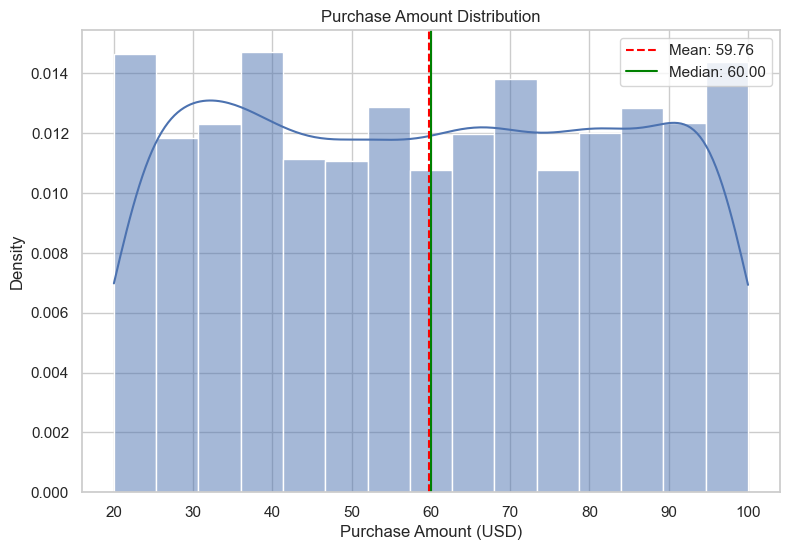

In [8]:
# Visualization 1: Purchase Amount Distribution
col = 'Purchase Amount (USD)'
if col in df.columns:
    fig, ax = plt.subplots(figsize=(9,6))
    sns.histplot(df[col].dropna(), kde=True, stat='density', color='C0', ax=ax)
    mean = df[col].mean()
    median = df[col].median()
    ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='-', label=f'Median: {median:.2f}')
    ax.set_title('Purchase Amount Distribution')
    ax.set_xlabel('Purchase Amount (USD)')
    ax.legend()
    save_fig(fig, '01_customer_purchase_distribution.png')
    plt.show()
else:
    print(f'Column {col} not found')

**Insights (Purchase Amount Distribution)**

- Distribution shape and skewness
- Central tendency (mean vs median) interpretation
- Any visible multi-modality or price clustering

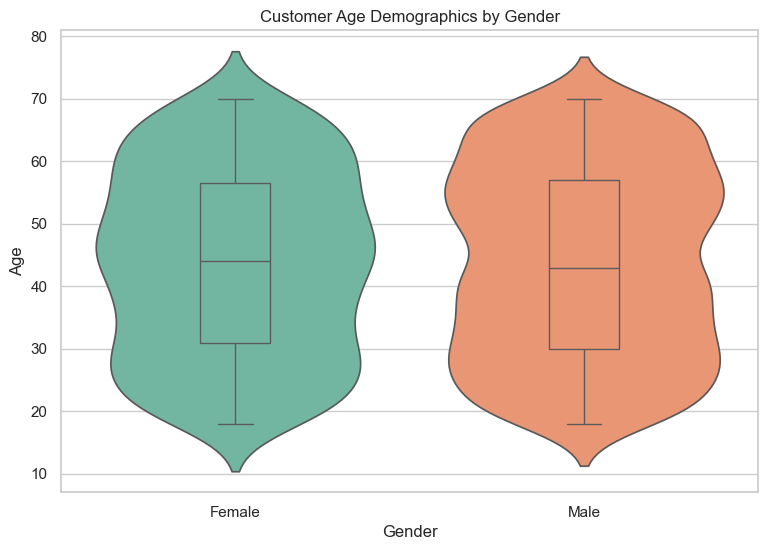

In [9]:
# Visualization 2: Age Demographics (violin + box)
if 'Age' in df.columns and 'Gender' in df.columns:
    fig, ax = plt.subplots(figsize=(9,6))
    sns.violinplot(x='Gender', y='Age', data=df, inner=None, palette='Set2', ax=ax)
    sns.boxplot(x='Gender', y='Age', data=df, width=0.2, showcaps=True, boxprops={'facecolor':'none'}, showfliers=True, ax=ax)
    ax.set_title('Customer Age Demographics by Gender')
    save_fig(fig, '02_age_demographics.png')
    plt.show()
else:
    print('Age or Gender column missing')

**Insights (Age Demographics)**

- Median age per gender
- Presence of outliers and age clusters
- Age segments to consider for targeting

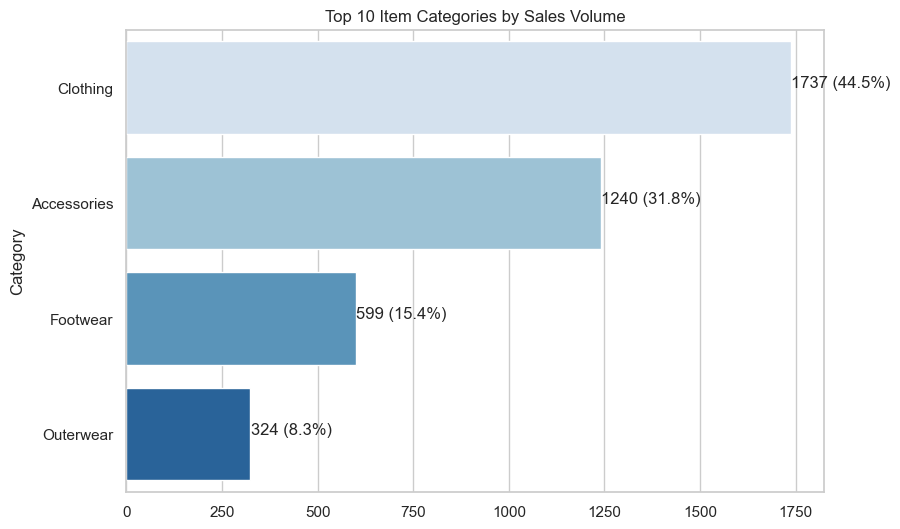

In [10]:
# Visualization 3: Top 10 Categories by Sales Volume
if 'Category' in df.columns:
    # normalize category text to avoid duplicates caused by casing/whitespace/unicode
    df['Category'] = df['Category'].astype(str).str.strip()
    df['Category'] = df['Category'].str.replace('\n', ' ', regex=False)
    df['Category'] = df['Category'].str.replace('\s+', ' ', regex=True)
    df['Category'] = df['Category'].apply(lambda x: unicodedata.normalize('NFKC', x))
    df['Category'] = df['Category'].str.title()
    ct = df['Category'].value_counts().nlargest(10)
    fig, ax = plt.subplots(figsize=(9,6))
    sns.barplot(x=ct.values, y=ct.index, palette='Blues', ax=ax)
    for i,v in enumerate(ct.values):
        ax.text(v+0.5, i, f'{v} ({v/ct.sum()*100:.1f}%)')
    ax.set_title('Top 10 Item Categories by Sales Volume')
    save_fig(fig, '03_category_sales_volume.png')
    plt.show()
else:
    print('Category column missing')

**Insights (Top Categories)**

- Which categories drive volume
- Percentage share of top categories
- Opportunities for cross-sell or expansion

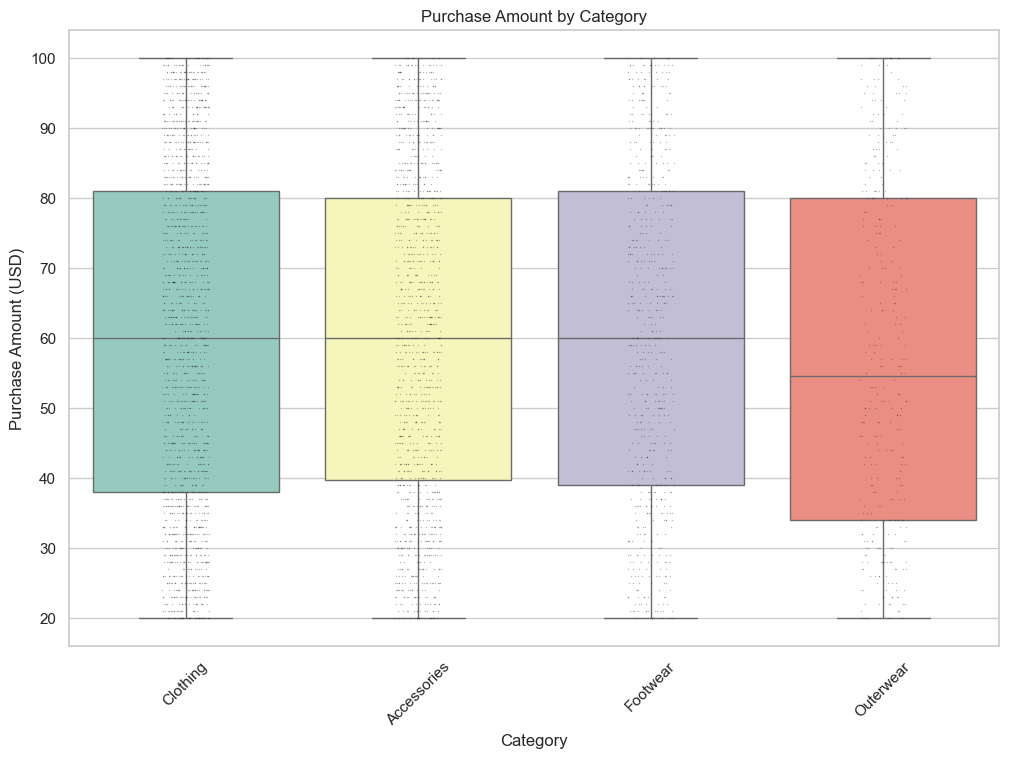

In [11]:
# Visualization 4: Purchase Amount by Category (boxplots)
if set(['Category','Purchase Amount (USD)']).issubset(df.columns):
    # ensure categories normalized same as previous plot (robust)
    df['Category'] = df['Category'].astype(str).str.strip()
    df['Category'] = df['Category'].str.replace('\n', ' ', regex=False)
    df['Category'] = df['Category'].str.replace('\s+', ' ', regex=True)
    df['Category'] = df['Category'].apply(lambda x: unicodedata.normalize('NFKC', x))
    df['Category'] = df['Category'].str.title()
    order = df['Category'].value_counts().nlargest(12).index
    fig, ax = plt.subplots(figsize=(12,8))
    sns.boxplot(x='Category', y='Purchase Amount (USD)', data=df, palette='Set3', showfliers=False, ax=ax, order=order)
    sns.stripplot(x='Category', y='Purchase Amount (USD)', data=df, color='k', size=1, alpha=0.3, ax=ax, order=order)
    ax.set_title('Purchase Amount by Category')
    plt.xticks(rotation=45)
    save_fig(fig, '04_purchase_by_category.png')
    plt.show()
else:
    print('Required columns missing')

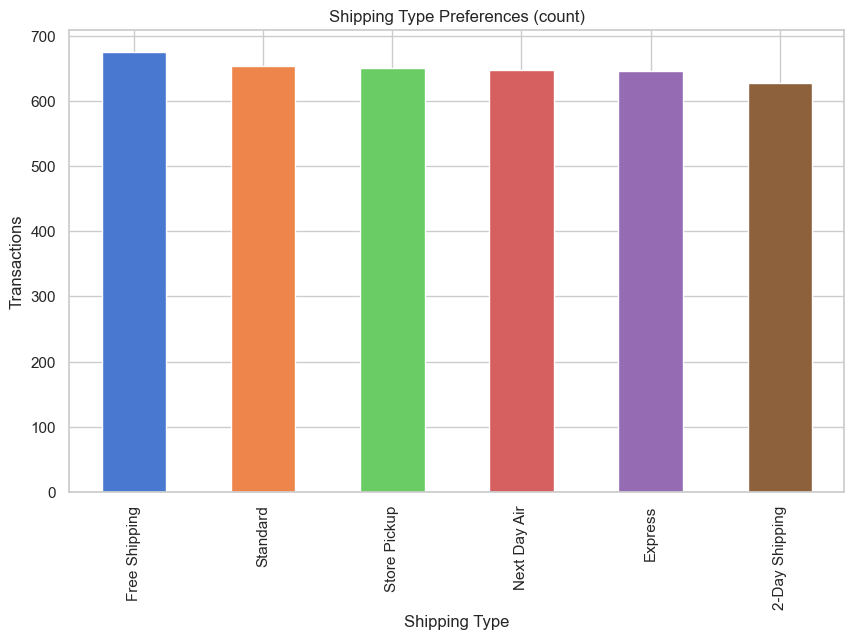

In [12]:
# Visualization 5: Shipping Type Preferences & Impact
if 'Shipping Type' in df.columns:
    grp = df.groupby('Shipping Type').agg({'Customer ID':'count','Review Rating':'mean','Discount Applied':lambda x: (x=='Yes').mean()}).rename(columns={'Customer ID':'count'})
    grp = grp.sort_values('count', ascending=False)
    fig, ax = plt.subplots(figsize=(10,6))
    grp['count'].plot(kind='bar', color=sns.color_palette('muted', len(grp)), ax=ax)
    ax.set_ylabel('Transactions')
    ax.set_title('Shipping Type Preferences (count)')
    save_fig(fig, '05_shipping_preferences.png')
    plt.show()
else:
    print('Shipping Type missing')

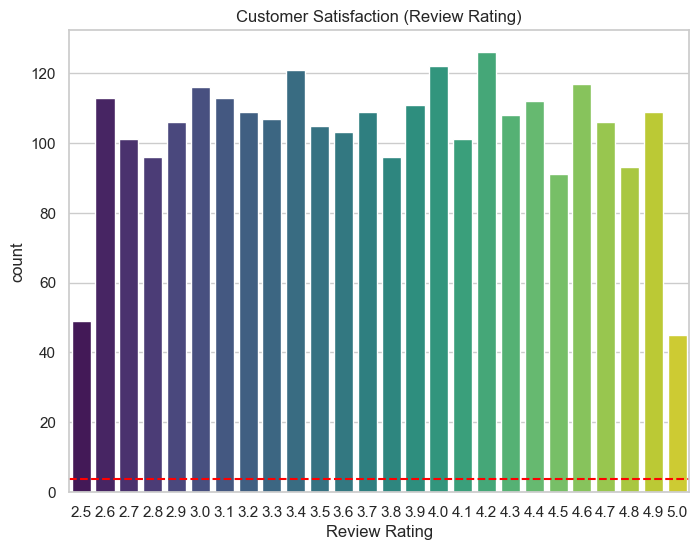

In [13]:
# Visualization 6: Customer Satisfaction (Review Rating)
if 'Review Rating' in df.columns:
    fig, ax = plt.subplots(figsize=(8,6))
    order = sorted(df['Review Rating'].dropna().unique())
    sns.countplot(x='Review Rating', data=df, palette='viridis', order=order, ax=ax)
    mean = df['Review Rating'].mean()
    ax.axhline(mean, color='red', linestyle='--')
    ax.set_title('Customer Satisfaction (Review Rating)')
    save_fig(fig, '06_satisfaction_analysis.png')
    plt.show()
else:
    print('Review Rating missing')

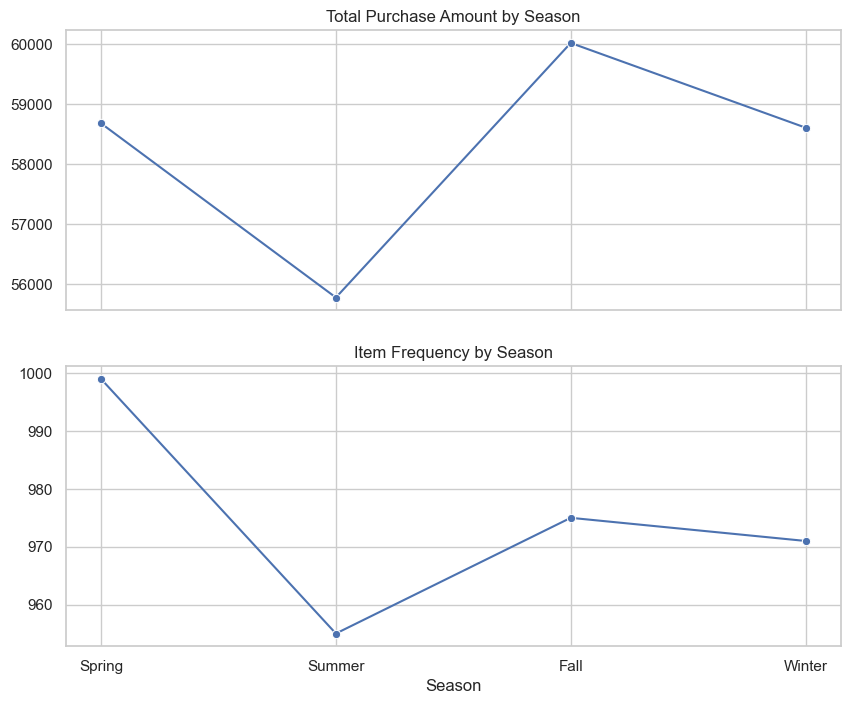

In [14]:
# Visualization 7: Seasonal Shopping Patterns
if 'Season' in df.columns:
    fig, axes = plt.subplots(2,1, figsize=(10,8), sharex=True)
    season_order = ['Spring','Summer','Fall','Winter']
    amt = df.groupby('Season')['Purchase Amount (USD)'].sum().reindex(season_order)
    freq = df['Season'].value_counts().reindex(season_order)
    sns.lineplot(x=amt.index, y=amt.values, marker='o', ax=axes[0])
    axes[0].set_title('Total Purchase Amount by Season')
    sns.lineplot(x=freq.index, y=freq.values, marker='o', ax=axes[1])
    axes[1].set_title('Item Frequency by Season')
    save_fig(fig, '07_seasonal_patterns.png')
    plt.show()
else:
    print('Season missing')

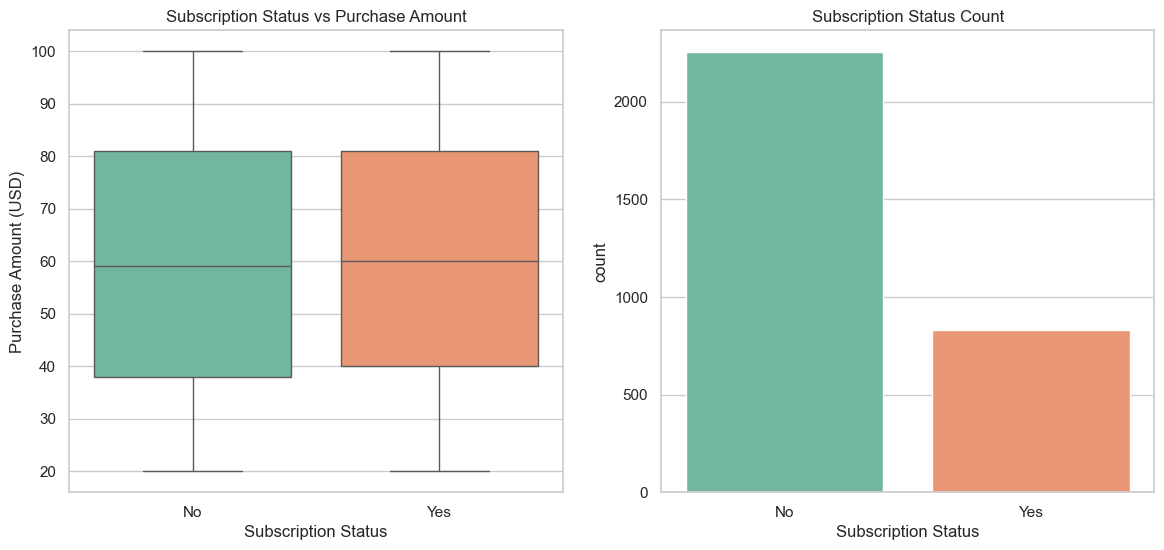

In [15]:
# Visualization 8: Subscription Status vs Purchase Behavior
if 'Subscription Status' in df.columns:
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    sns.boxplot(x='Subscription Status', y='Purchase Amount (USD)', data=df, ax=axes[0], palette='Set2')
    sns.countplot(x='Subscription Status', data=df, ax=axes[1], palette='Set2')
    axes[0].set_title('Subscription Status vs Purchase Amount')
    axes[1].set_title('Subscription Status Count')
    save_fig(fig, '08_subscription_impact.png')
    plt.show()
else:
    print('Subscription Status missing')

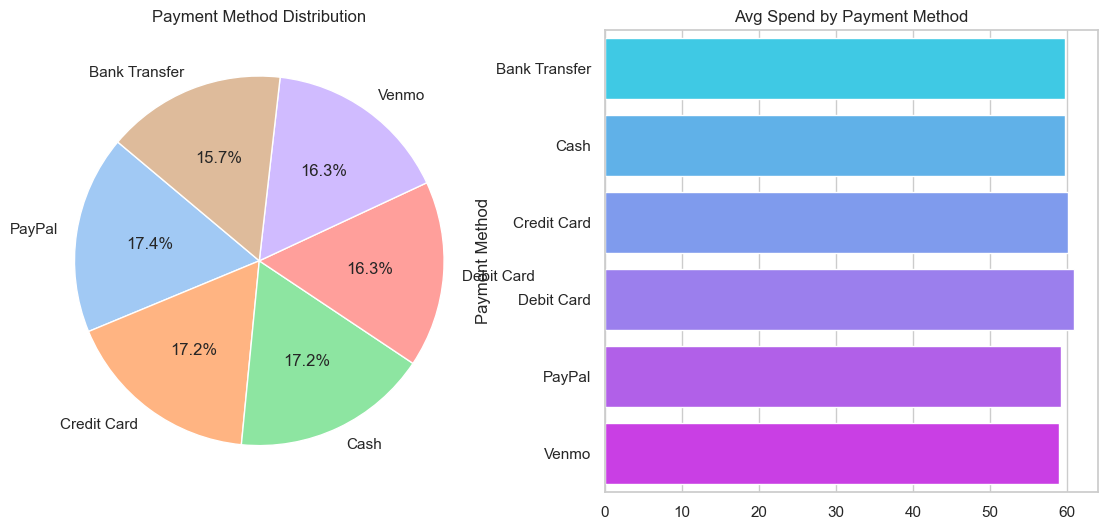

In [16]:
# Visualization 9: Payment Method Distribution & Avg Spend
if 'Payment Method' in df.columns:
    counts = df['Payment Method'].value_counts()
    avg = df.groupby('Payment Method')['Purchase Amount (USD)'].mean().sort_values(ascending=False)
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    axes[0].set_title('Payment Method Distribution')
    sns.barplot(x=avg.values, y=avg.index, ax=axes[1], palette='cool')
    axes[1].set_title('Avg Spend by Payment Method')
    save_fig(fig, '09_payment_methods.png')
    plt.show()
else:
    print('Payment Method missing')

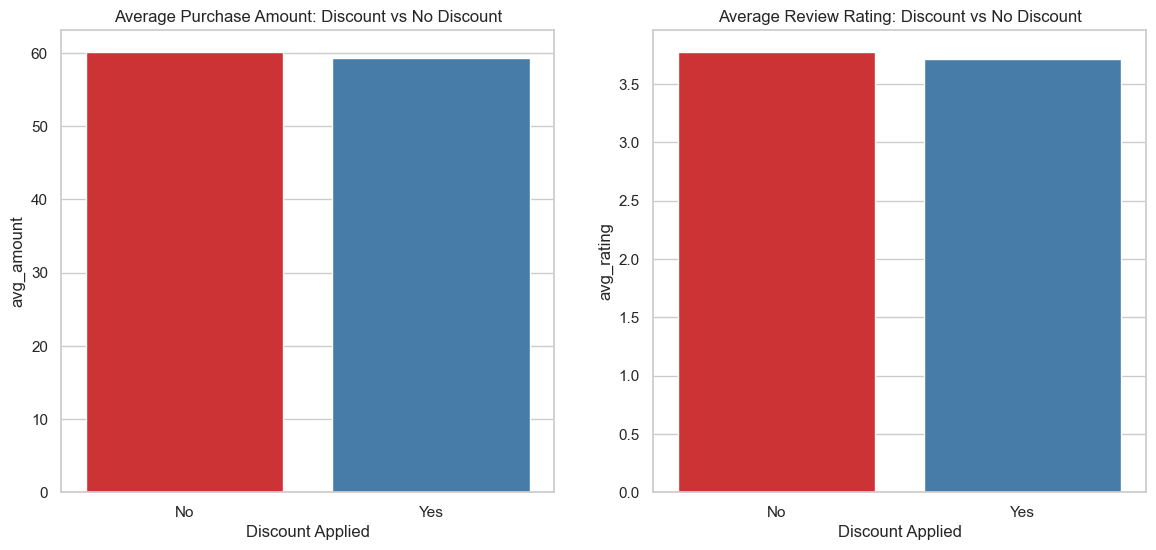

In [17]:
# Visualization 10: Discount & Promo Code Effectiveness
if 'Discount Applied' in df.columns:
    grp = df.groupby('Discount Applied').agg({'Purchase Amount (USD)':['mean','count'],'Review Rating':'mean'})
    grp.columns = ['avg_amount','count','avg_rating']
    fig, axes = plt.subplots(1,2, figsize=(14,6))
    sns.barplot(x=grp.index, y='avg_amount', data=grp.reset_index(), ax=axes[0], palette='Set1')
    sns.barplot(x=grp.index, y='avg_rating', data=grp.reset_index(), ax=axes[1], palette='Set1')
    axes[0].set_title('Average Purchase Amount: Discount vs No Discount')
    axes[1].set_title('Average Review Rating: Discount vs No Discount')
    save_fig(fig, '10_discount_effectiveness.png')
    plt.show()
else:
    print('Discount Applied missing')

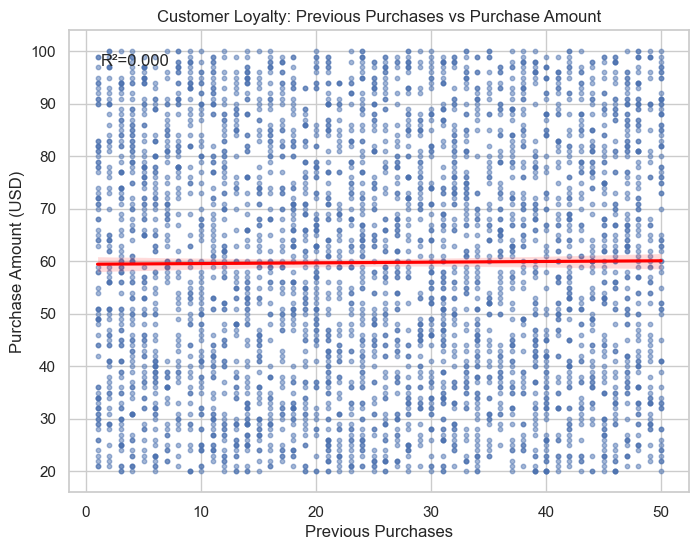

In [18]:
# Visualization 11: Customer Loyalty (Previous Purchases vs Purchase Amount)
if 'Previous Purchases' in df.columns:
    fig, ax = plt.subplots(figsize=(8,6))
    sns.regplot(x='Previous Purchases', y='Purchase Amount (USD)', data=df, scatter_kws={'s':10,'alpha':0.5}, line_kws={'color':'red'}, ax=ax)
    ax.set_title('Customer Loyalty: Previous Purchases vs Purchase Amount')
    clean = df[['Previous Purchases','Purchase Amount (USD)']].dropna()
    if len(clean)>2:
        slope, intercept, r_value, p_value, std_err = stats.linregress(clean['Previous Purchases'], clean['Purchase Amount (USD)'])
        ax.text(0.05,0.95, f'R²={r_value**2:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top')
    save_fig(fig, '11_customer_loyalty.png')
    plt.show()
else:
    print('Previous Purchases missing')

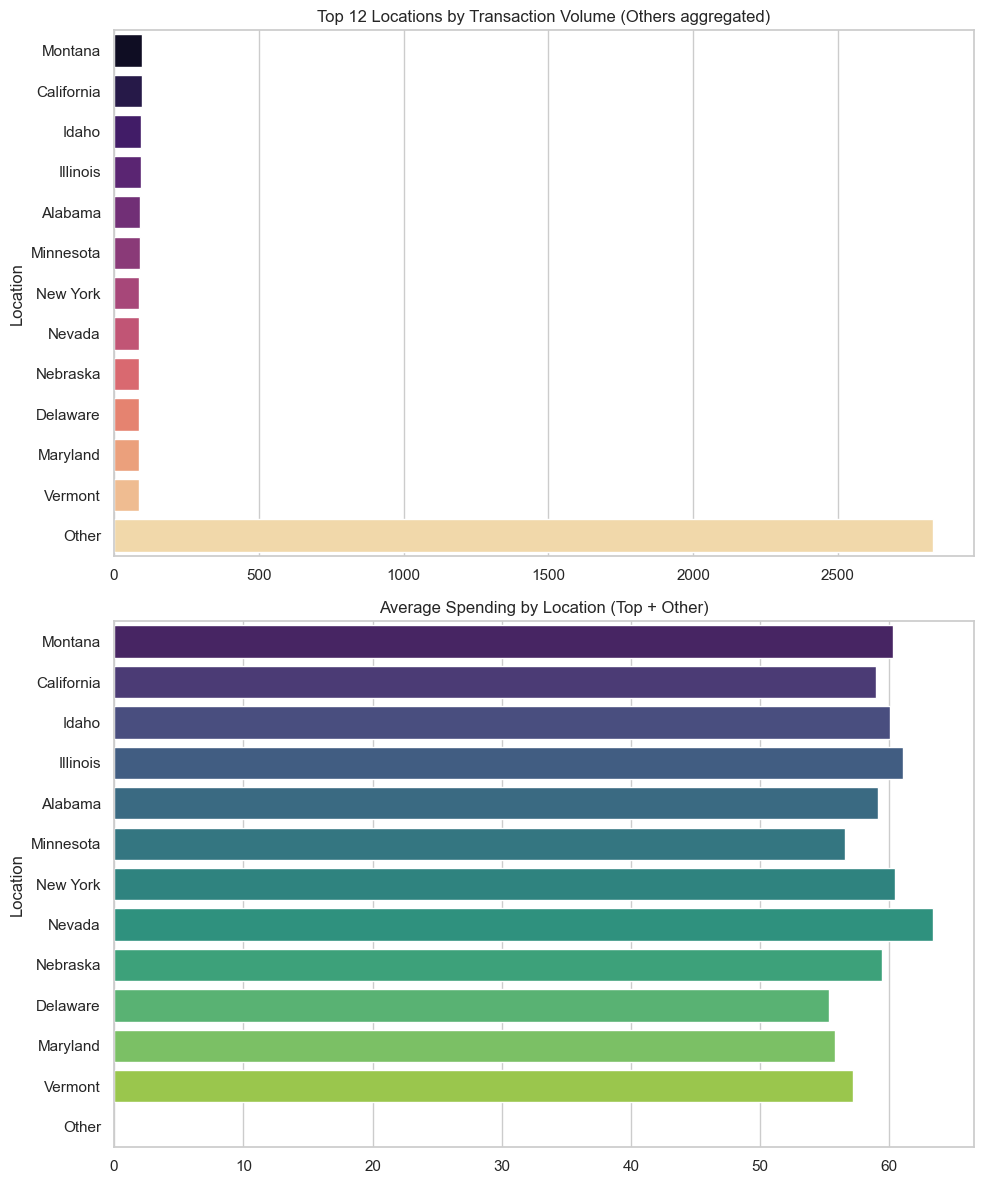

In [19]:
# Visualization 12: Geographic Distribution
if 'Location' in df.columns:
    # normalize location strings
    df['Location'] = df['Location'].astype(str).str.strip().str.replace('\n',' ', regex=False)
    df['Location'] = df['Location'].str.replace('\s+', ' ', regex=True).str.title()
    loc_counts = df['Location'].value_counts()
    top_n = 12
    top = loc_counts.nlargest(top_n).copy()
    others = loc_counts.iloc[top_n:].sum()
    if others > 0:
        top.loc['Other'] = others
    avg = df.groupby('Location')['Purchase Amount (USD)'].mean().reindex(top.index)
    fig, axes = plt.subplots(2,1, figsize=(10,12))
    sns.barplot(x=top.values, y=top.index, palette='magma', ax=axes[0])
    axes[0].set_title(f'Top {top_n} Locations by Transaction Volume (Others aggregated)')
    sns.barplot(x=avg.values, y=avg.index, palette='viridis', ax=axes[1])
    axes[1].set_title('Average Spending by Location (Top + Other)')
    plt.tight_layout()
    save_fig(fig, '12_geographic_distribution.png')
    plt.show()
else:
    print('Location missing')

## Bivariate & Multivariate Analysis

Correlation matrix, crosstabs, chi-square tests, and visual comparisons.

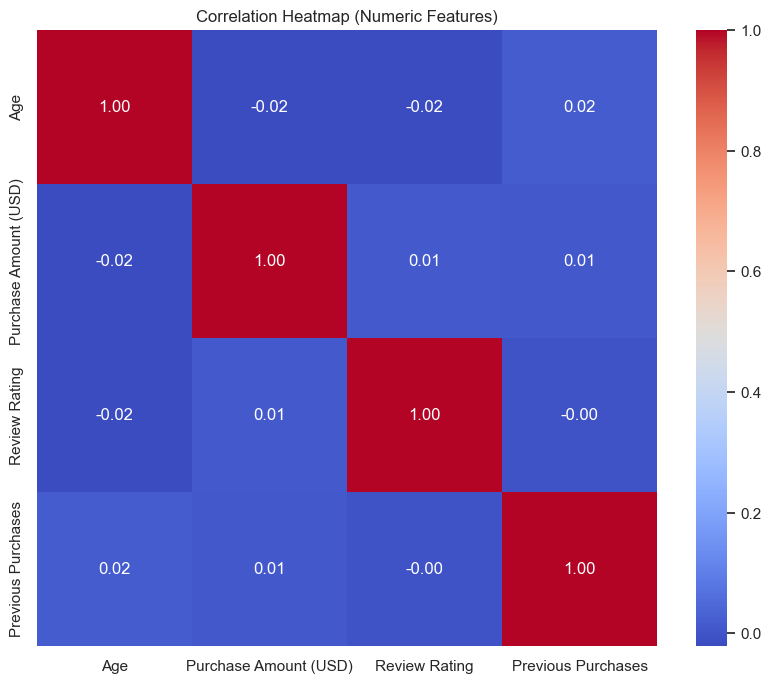

,feature_a,feature_b,corr


,var_a,var_b,chi2,p
9,Item Purchased,Category,11700.000000,0.000000
8,Gender,Size,6.615108,0.085232
13,Category,Size,8.994198,0.437810
5,Gender,Item Purchased,24.250852,0.447330
3,Customer ID,Location,191100.000000,0.467983


In [20]:
# Correlation heatmap
num = df.select_dtypes(include=[np.number])
if num.shape[1]>1:
    fig, ax = plt.subplots(figsize=(10,8))
    corr = num.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
    ax.set_title('Correlation Heatmap (Numeric Features)')
    save_fig(fig, 'correlation_heatmap.png')
    plt.show()
    strong = []
    for i in corr.columns:
        for j in corr.index:
            if i!=j and abs(corr.loc[j,i])>0.6:
                strong.append((j,i,corr.loc[j,i]))
    strong_df = pd.DataFrame(strong, columns=['feature_a','feature_b','corr'])
    strong_df.to_csv(OUTPUT_DIR / 'strong_correlations.csv', index=False)
    display(strong_df.head())
else:
    print('Not enough numeric features for correlation matrix')
from scipy.stats import chi2_contingency
cat_cols = df.select_dtypes(include=['category','object']).columns.tolist()
chi_results = []
for i in range(min(6,len(cat_cols))):
    for j in range(i+1, min(6,len(cat_cols))):
        a = cat_cols[i]; b = cat_cols[j]
        ct = pd.crosstab(df[a], df[b])
        if ct.size==0: continue
        try:
            chi2, p, dof, ex = chi2_contingency(ct)
            chi_results.append((a,b,chi2,p))
        except Exception:
            continue
chi_df = pd.DataFrame(chi_results, columns=['var_a','var_b','chi2','p']).sort_values('p')
chi_df.to_csv(OUTPUT_DIR / 'chi_square_results.csv', index=False)
display(chi_df.head())

## Customer Segmentation

Segment by purchase frequency and spending to create customer profiles and identify high-value customers.

In [21]:
# Segmentation: frequency mapping
mapping = {'Weekly':52,'Monthly':12,'Quarterly':4,'Yearly':1}
if 'Frequency of Purchases' in df.columns:
    seg = df.copy()
    seg['freq_per_year'] = seg['Frequency of Purchases'].map(mapping).fillna(0)
    seg['spend_bucket'] = pd.qcut(seg['Purchase Amount (USD)'].fillna(0), q=4, labels=['Low','Medium','High','Very High'])
    seg['segment'] = pd.cut(seg['freq_per_year'], bins=[-1,1,6,12,999], labels=['Very Low','Low','Medium','High'])
    seg[['Customer ID','freq_per_year','spend_bucket','segment']].to_csv(OUTPUT_DIR / 'customer_segments.csv', index=False)
    display(seg.groupby('segment')['Purchase Amount (USD)'].agg(['count','mean','median']))
else:
    print('Frequency of Purchases missing; creating spend-only segments')
    seg = df.copy()
    seg['spend_bucket'] = pd.qcut(seg['Purchase Amount (USD)'].fillna(0), q=4, labels=['Low','Medium','High','Very High'])
    seg.to_csv(OUTPUT_DIR / 'customer_segments_spend_only.csv', index=False)
    display(seg['spend_bucket'].value_counts())

,count,mean,median
segment,,,
Very Low,2245,60.006236,60.0
Low,563,59.984014,61.0
Medium,553,59.330922,58.0
High,539,58.972171,58.0


## Statistical Tests

T-tests, ANOVA, and correlation tests for the hypotheses specified in the project brief.

In [22]:
with open(OUTPUT_DIR / 'statistical_tests_results.txt','w') as fout:
    # T-test male vs female
    if set(['Gender','Purchase Amount (USD)']).issubset(df.columns):
        male = df[df['Gender']=='Male']['Purchase Amount (USD)'].dropna()
        female = df[df['Gender']=='Female']['Purchase Amount (USD)'].dropna()
        try:
            tstat, pval = stats.ttest_ind(male, female, equal_var=False)
            fout.write(f'Male vs Female t-test: t={tstat:.4f}, p={pval:.4e}\n')
        except Exception as e:
            fout.write('T-test error: '+str(e)+'\n')
    # ANOVA subscription status
    if set(['Subscription Status','Purchase Amount (USD)']).issubset(df.columns):
        groups = [g['Purchase Amount (USD)'].dropna() for n,g in df.groupby('Subscription Status')]
        try:
            fstat, pval = stats.f_oneway(*groups)
            fout.write(f'ANOVA Subscription: F={fstat:.4f}, p={pval:.4e}\n')
        except Exception as e:
            fout.write('ANOVA error: '+str(e)+'\n')
    # Discount vs Rating correlation (point-biserial)
    if set(['Discount Applied','Review Rating']).issubset(df.columns):
        clean = df.dropna(subset=['Discount Applied','Review Rating'])
        if clean['Discount Applied'].nunique()==2:
            cat_map = {k:i for i,k in enumerate(sorted(clean['Discount Applied'].unique()))}
            x = clean['Discount Applied'].map(cat_map)
            r, p = stats.pearsonr(x, clean['Review Rating'])
            fout.write(f'Correlation Discount-Rating: r={r:.4f}, p={p:.4e}\n')
print('Saved statistical_tests_results.txt')
with open(OUTPUT_DIR / 'statistical_tests_results.txt') as f:
    print(f.read())

Saved statistical_tests_results.txt
Male vs Female t-test: t=-0.8821, p=3.7779e-01
ANOVA Subscription: F=0.1453, p=7.0310e-01
Correlation Discount-Rating: r=-0.0431, p=2.5428e-02



## Final Insights & Recommendations

This cell will summarize key findings, business recommendations, and data quality notes into a text file.

In [23]:
insights = []
# Example: top categories
if 'Category' in df.columns:
    top5 = df['Category'].value_counts().nlargest(5)
    insights.append('Top categories by volume: ' + ', '.join([f'{i} ({v})' for i,v in zip(top5.index, top5.values)]))
# Example: avg purchase
if 'Purchase Amount (USD)' in df.columns:
    insights.append(f"Avg purchase amount: ${df['Purchase Amount (USD)'].mean():.2f}")
# Write recommendations (placeholder templates)
recommendations = [
    'Focus promotions on top categories to increase cross-sell.',
    'Test targeted campaigns for age segments with high avg spend.',
    'Prioritize shipping options that correlate with higher satisfaction.'
]
with open(OUTPUT_DIR / 'final_insights_and_recommendations.txt','w') as f:
    f.write('Key Findings:\n')
    for s in insights:
        f.write('- '+s+'\n')
    f.write('\nRecommendations:\n')
    for r in recommendations:
        f.write('- '+r+'\n')
print('Saved final_insights_and_recommendations.txt')
print('\n'.join(insights))

Saved final_insights_and_recommendations.txt
Top categories by volume: Clothing (1737), Accessories (1240), Footwear (599), Outerwear (324)
Avg purchase amount: $59.76


## Run All (End-to-end)

Use this cell to re-run main steps (data reload, conversions, plots and reports). This is useful to re-generate artifacts after changes.

In [24]:
# Minimal run-all wrapper (repeats key steps). Uncomment to execute end-to-end.
# Note: Running cell-by-cell is recommended for inspection.
# %run -i analysis_script.py
print('Notebook populated. Run cells sequentially, or use the run-all button.')

Notebook populated. Run cells sequentially, or use the run-all button.
